# AI Engineer Assignment - Virallens

## **Q2 – Custom Embedder for Domain Documents - Research Files/Notebook**

Given the sample documents:

- Create a **domain-specific embedder**.
- Generate embeddings and perform clustering (any traditional methods).
- Compare performance against a baseline embedding model using:
  - similarity checks  
  - clustering separation metrics (e.g., silhouette score)
#### Note: Only the approach will be evaluated here - There is no need to have long embedding lengths

**Deliverables**
- Code for preprocessing, training, embedding, and clustering, seperate python files or seperate sections in a notebook.
- **3–5 metrics or visualizations** (plots, cluster maps, neighbor checks).
- A **short summary** describing findings, challenges, and model behavior.
- **Raw dump** of any resources reffered.


## Reading the dataset

In [131]:
import fitz
import random
import pandas as pd
from pathlib import Path
from rich import print as rich_print

In [158]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [159]:
# Iterating through the raw dir

CURR_DIR = Path('.').resolve()
DATA_DIR = CURR_DIR.parent / 'data' / 'raw'
SAVE_PATH = CURR_DIR / 'custom-embedder'

def read_pdf(filepath: Path):
    parts = []
    with fitz.open(str(filepath)) as doc:
        for page in doc:
            parts.append(page.get_text('text'))
    return '\n'.join(parts)

records: list[dict] = []
for idx, filepath in enumerate(DATA_DIR.glob('*.pdf'), start=1):
    print(f'Reading {filepath}')
    content = read_pdf(filepath)
    records.append({
        'document_id': idx,
        'text': content,
        'source_file': filepath.name
    })

df = pd.DataFrame(records)

Reading /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/data/raw/USCOURTS-ilnd-1_04-cv-00397-5.pdf
Reading /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/data/raw/22-1165_10n2.pdf
Reading /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/data/raw/23-980bsacus_facebookvamalgamatedbank.pdf
Reading /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/data/raw/20240809133545974_23-980_petbrief.pdf
Reading /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/data/raw/comp26286.pdf


In [160]:
df

,document_id,text,source_file
0,1,IN THE UNITED STATES DISTRICT COURT\nFOR THE N...,USCOURTS-ilnd-1_04-cv-00397-5.pdf
1,2,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n ...,22-1165_10n2.pdf
2,3,\n \nNo. 23-980 \nIn the Supreme Court of the...,23-980bsacus_facebookvamalgamatedbank.pdf
3,4,No. 23-980 \nIn the Supreme Court of the Unite...,20240809133545974_23-980_petbrief.pdf
4,5,\nCorey A. Schuster \nLee A. Greenwood \nDebr...,comp26286.pdf


## Text Preprocessing

Taking help from this gist :D

https://gist.github.com/ghadj/507e53effcf7fa9e873b3ed485723527

In [135]:
import re
import html

In [163]:
def preprocess_text(text: str):
    # Non printable control chars
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
    # Unusual unicode whitespaces
    text = re.sub(r"[\u00a0\u200b\u200c\u200d\u202f\u2009\u2028\u2029\ufeff]", " ", text)
    # Collapse 3+ newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    # HTML (if any)
    text = html.unescape(text)
    # Collapse multiple spaces
    text = re.sub(r' {2,}', ' ', text)
    # Strip each line
    text = '\n'.join(line.strip() for line in text.splitlines())
    # Removing non-ascii stuff
    text.encode('ascii', 'ignore').decode('ascii')
    # Final strip
    return text.strip()


def preprocess_text(text: str) -> str:
    """
    Clean raw extracted text while preserving semantic content.

    Pipeline
    --------
    1. Strip non-printable control chars (keep \\n, \\t)
    2. Normalise unicode whitespace variants → regular space
    3. Convert tabs → spaces
    4. Collapse 3+ consecutive newlines → double newline (paragraph break)
    5. Collapse runs of multiple spaces → single space
    6. Strip leading / trailing whitespace on each line
    7. Final full-string strip
    """
    # 1. Remove non-printable control characters (preserve \n \t)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)

    # 2. Normalise unusual unicode whitespace
    text = re.sub(r"[\u00a0\u200b\u200c\u200d\u202f\u2009\u2028\u2029\ufeff]", " ", text)

    # 3. Tabs → spaces
    text = text.replace("\t", " ")

    # 4. Collapse 3+ newlines → paragraph break
    text = re.sub(r"\n{3,}", "\n\n", text)

    # 5. Collapse multiple spaces
    text = re.sub(r" {2,}", " ", text)

    # 6. Strip each line
    text = "\n".join(line.strip() for line in text.splitlines())

    # 7. Final strip
    return text.strip()

df['text'] = df.text.apply(preprocess_text)

In [164]:
# Some stats on the documents now

char_lens = df.text.str.len()
wc = df.text.str.split().str.len()

print('Total docs:', df.shape[0])
print('Total chars:', char_lens.sum())
print('Estimated total words (post process):', wc.sum())
print('Avg. chars / doc:', char_lens.mean())
print('Avg. words / doc:', wc.mean())

Total docs: 5
Total chars: 278642
Estimated total words (post process): 43271
Avg. chars / doc: 55728.4
Avg. words / doc: 8654.2


## Chunking

**Params**

* `chunk_size` - 500 chars
* `chunk_ovelap` - 100 chars (20%)

In [138]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [139]:
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']
)

In [140]:
# Performing chunking on the docs (so far they're intact)

# We'll create a new DF with this 'rows'
rows = []

for _, row in df.iterrows():
    chunks = splitter.split_text(row.text)

    # Iterating through the chunks & adding metadata
    for idx, chunk in enumerate(chunks):
        chunk = chunk.strip()
        if len(chunk) < 30:
            continue
        rows.append({
            'chunk_id': f'{row.document_id}_{idx}',
            'document_id': row.document_id,
            'source_file': row.source_file,
            'text': chunk
        })

cols = 'chunk_id document_id source_file text'.split()
chunked_df = pd.DataFrame(rows, columns=cols)

In [166]:
chunk_lens = chunked_df.text.str.len()
per_doc = chunked_df.groupby('document_id').size()


print('Total chunks:', chunked_df.shape[0])
print(f'Chunks per doc (mean): {per_doc.mean()}')
print(f'Chunks per doc (max): {per_doc.max()}')
print('Avg. chunk length (chars):', chunk_lens.mean())
print(f'Min / Max chunk length: {chunk_lens.min()} / {chunk_lens.max()}')

Total chunks: 753
Chunks per doc (mean): 150.6
Chunks per doc (max): 241
Avg. chunk length (chars): 414.42231075697214
Min / Max chunk length: 65 / 499


## Baseline Embedding Generation

In [167]:
from sentence_transformers import SentenceTransformer

In [168]:
BASELINE_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
ENCODE_BATCH_SIZE = 32

print(f'Loading baseline model: {BASELINE_MODEL}')
baseline = SentenceTransformer(BASELINE_MODEL)

Loading baseline model: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|███████████| 103/103 [00:00<00:00, 10078.46it/s]


In [169]:
chunk_texts = chunked_df.text.tolist()
print(f'Encoding {len(chunk_texts)} chunks...')

baseline_embeddings = baseline.encode(
    chunk_texts,
    batch_size=ENCODE_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

Encoding 753 chunks...


Batches: 100%|████████████████████████| 24/24 [00:02<00:00,  8.54it/s]


In [170]:
# Embedding stats

print(f"Embedding shape: {baseline_embeddings.shape}")
print(f"Embedding dimensions: {baseline_embeddings.shape[1]}")
print(f"Chunks encoded: {baseline_embeddings.shape[0]}")

Embedding shape: (753, 384)
Embedding dimensions: 384
Chunks encoded: 753


## Domain Adaptation Strategy

Using Contrastive Learning, this teacher an encoder to
* Pull together representations of semantically similar examples
* Push apart representations of dissimilar examples

### Pseudo-Supervised Training Pairs

We're going to try and construct training pairs from the corpus structure itself, where

* **Positive pairs** are semantically related and have label = `1`
* **Negative pairs** since we're gonna be using `MultipleNegativesRankingLoss` we wont need to supply explicit negative pairs. Within each mini-batch, every other anchor's positive pair acts as an implicit negative.

In [146]:
from sentence_transformers import InputExample

In [171]:
def jaccard_overlap(text_a: str, text_b: str, min_len: int = 4) -> float:
    """
    Jaccard similarity over the set of content words (length >= min_len).
    Acts as a lightweight proxy for topical similarity.
    """
    words_a = {w.lower() for w in re.findall(r"\b\w+\b", text_a) if len(w) >= min_len}
    words_b = {w.lower() for w in re.findall(r"\b\w+\b", text_b) if len(w) >= min_len}
    if not words_a or not words_b:
        return 0.0
    return len(words_a & words_b) / len(words_a | words_b)

In [172]:
def generate_training_pairs(
    chunks: pd.DataFrame,
    neighbor_window: int = 2,
    n_lexical_per_doc: int = 40,
    lexical_threshold: float = 0.15,
) -> list[InputExample]:
    """
    Build pseudo-supervised positive pairs for contrastive fine-tuning.

    Strategy 1 — Neighboring chunks
        For each document, pair every chunk with the next `neighbor_window` chunks.
        Assumption: consecutive chunks share context and topic.

    Strategy 2 — High lexical overlap
        Randomly sample chunk pairs within the same document; keep those with
        Jaccard overlap >= `lexical_threshold`.
        Assumption: chunks sharing many content words cover the same topic.

    Returns a list og InputExamples where each example is a (text_a, text_b) positive pair.
    """
    examples: List[InputExample] = []
    doc_groups = {doc_id: grp.reset_index(drop=True)
                  for doc_id, grp in chunks.groupby("document_id")}

    # Neighboring chunks
    n_before = 0
    for doc_id, group in doc_groups.items():
        texts = group["text"].tolist()
        for i in range(len(texts)):
            for j in range(i + 1, min(i + 1 + neighbor_window, len(texts))):
                examples.append(InputExample(texts=[texts[i], texts[j]]))
                n_before += 1

    print(f"[Strategy 1] Neighbor pairs: {n_before}")

    # Lexical overlap
    n_lexical = 0
    for doc_id, group in doc_groups.items():
        texts = group["text"].tolist()
        if len(texts) < 3:
            continue
        candidates = [(i, j)
                      for i in range(len(texts))
                      for j in range(i + 2, len(texts))]  # skip immediate neighbors
        random.shuffle(candidates)
        added = 0
        for i, j in candidates:
            if added >= n_lexical_per_doc:
                break
            if jaccard_overlap(texts[i], texts[j]) >= lexical_threshold:
                examples.append(InputExample(texts=[texts[i], texts[j]]))
                n_lexical += 1
                added += 1

    print(f"[Strategy 2] Lexical pairs: {n_lexical}")

    random.shuffle(examples)
    return examples


In [173]:
training_examples = generate_training_pairs(chunked_df)

[Strategy 1] Neighbor pairs: 1491
[Strategy 2] Lexical pairs: 200


In [174]:
temp = training_examples[0]
print(f'Text A -- {temp.texts[0][:300]}')
print('=='*30)
print(f'Text B -- {temp.texts[1][:300]}')

Text A -- based on implied misrepresentations. Under the “shingle theory,”
a broker-dealer that “does business with the public . . . impliedly
represents that he will deal fairly with the public.” Brennan v.
Midwestern United Life Ins. Co., 286 F. Supp. 702 (N.D. Ind. 1968).
“[A] broker-dealer, by accepting a
Text B -- In support of its assertion that an express representation is
required for a specialist to be liable under Rule 10b-5, Knight
points me to the Second Circuit opinion in United States v.
Finnerty, 533 F.3d 143 (2d Cir. 2008) (“Finnerty III”). Rather
frustratingly, Knight glosses over the subtleties o


## Fine Tuning the Embedder

In [177]:
from datasets import Dataset as HFDataset
from sentence_transformers.sentence_transformer.losses import MultipleNegativesRankingLoss
from sentence_transformers.sentence_transformer.training_args import SentenceTransformerTrainingArguments
from sentence_transformers.sentence_transformer.trainer import SentenceTransformerTrainer

In [178]:
TRAIN_BATCH_SIZE = 16
NUM_EPOCHS = 2
WARMUP_RATIO = 0.10

In [179]:
print(f'Loading model for fine-tuning: {BASELINE_MODEL}')
adapted = SentenceTransformer(BASELINE_MODEL)

Loading model for fine-tuning: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|███████████| 103/103 [00:00<00:00, 22798.74it/s]


Building HugginFace Data from training pairs

In [180]:
train_dataset = HFDataset.from_dict({
    'anchor': [x.texts[0] for x in training_examples],
    'positive': [x.texts[1] for x in training_examples]
})

In [181]:
loss = MultipleNegativesRankingLoss(model=adapted)

In [185]:
# Training args

total_steps  = (len(train_dataset) // TRAIN_BATCH_SIZE) * NUM_EPOCHS
warmup_steps = WARMUP_RATIO

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')

training_args = SentenceTransformerTrainingArguments(
    output_dir=str(SAVE_PATH),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    learning_rate=2e-5,
    warmup_steps=warmup_steps,
    seed=RANDOM_SEED,
    save_strategy='no',
    logging_steps=20,
    fp16=False,
    report_to='none'
)

print(f"\nTraining configuration:")
print(f"Training examples: {len(train_dataset)}")
print(f"Batch size: {TRAIN_BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Total steps (estimated): {total_steps}")
print(f"Warmup fraction: {WARMUP_RATIO:.0%}")

Total steps: 210
Warmup steps: 0.1

Training configuration:
Training examples: 1691
Batch size: 16
Epochs: 2
Total steps (estimated): 210
Warmup fraction: 10%


In [186]:
# Training
trainer = SentenceTransformerTrainer(
    model=adapted,
    args=training_args,
    train_dataset=train_dataset,
    loss=loss,
)

trainer.train()

/Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
20,1.845282
40,1.830070
60,1.550794
80,1.489390
100,1.572596
120,1.351851
140,1.184425
160,1.223361
180,1.251161
200,1.248697


TrainOutput(global_step=212, training_loss=1.4340332499090231, metrics={'train_runtime': 106.412, 'train_samples_per_second': 31.782, 'train_steps_per_second': 1.992, 'total_flos': 0.0, 'train_loss': 1.4340332499090231, 'epoch': 2.0})

In [187]:
# Saving the weights
adapted.save_pretrained(str(SAVE_PATH))

Writing model shards: 100%|█████████████| 1/1 [00:00<00:00, 12.50it/s]


## Generating Embeddings using `adapted`

In [189]:
print(f'Loading fine-runed model from {SAVE_PATH}')
adapted_model = SentenceTransformer(str(SAVE_PATH))

Loading fine-runed model from /Users/praneshmukhopadhyay/Projects/AgenticRAG-VL/q2/custom-embedder


Loading weights: 100%|███████████| 103/103 [00:00<00:00, 11261.49it/s]


In [190]:
# Encoding using this new model
# chunk_texts = chunked_df.text.tolist()
print(f'Encoding {len(chunk_texts)} chunks...')

adapted_embeddings = adapted_model.encode(
    chunk_texts,
    batch_size=ENCODE_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

Encoding 753 chunks...


Batches: 100%|████████████████████████| 24/24 [00:02<00:00,  9.32it/s]


In [191]:
# Double check the shapes
print(f'Baseline embeddings shape: {baseline_embeddings.shape}')
print(f'Adapted embeddings shape: {adapted_embeddings.shape}')

Baseline embeddings shape: (753, 384)
Adapted embeddings shape: (753, 384)


In [193]:
# Checking the dot-products (How much did the embeddings change?)

dot_prods = (baseline_embeddings * adapted_embeddings).sum(axis=1)
dot_prods.mean()

np.float32(0.8653369)

## Clustering

In [205]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

In [206]:
n_docs = len(df)
max_k = min(15, max(2, len(chunked_df) // 3))

# Params for choosing k value
print(f'Number of original docs: {n_docs}')
print(f'Max allowed k: {max_k}')

Number of original docs: 5
Max allowed k: 15


### Elbow method

Running elbow analysis...


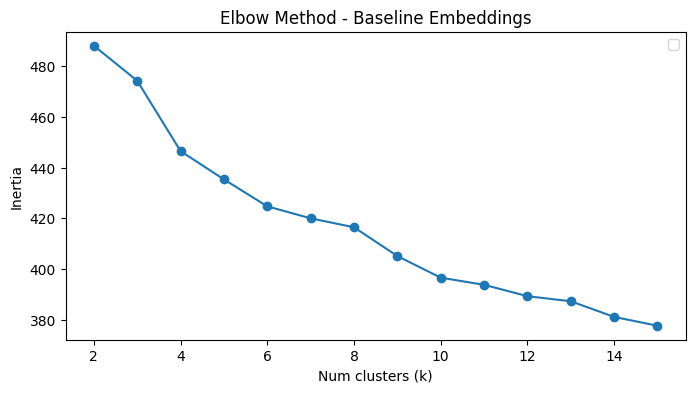

In [209]:
inertias: list[float] = []

print('Running elbow analysis...')

for k in range(2, max_k + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init='auto')
    km.fit(baseline_embeddings)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(range(2, max_k + 1)), inertias, marker='o')
ax.set_title('Elbow Method - Baseline Embeddings')
ax.set_xlabel('Num clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
plt.savefig('elbow_curve.png', dpi=120, bbox_inches='tight')
plt.show()

Based on the above plot, we're choosing k value to be `6`

In [210]:
# Generating labels for both baseline & adapted embeddings

N_CLUSTERS = 6

km_baseline = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init='auto')
baseline_labels = km_baseline.fit_predict(baseline_embeddings)

km_adapted = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init='auto')
adapted_labels = km_adapted.fit_predict(adapted_embeddings)

In [211]:
# Storing the labels
chunked_df['baseline_cluster'] = baseline_labels
chunked_df['adapted_cluster'] = adapted_labels

In [212]:
chunked_df.baseline_cluster.value_counts()

baseline_cluster
0    162
2    128
1    121
4    118
3    116
5    108
Name: count, dtype: int64

In [213]:
chunked_df.adapted_cluster.value_counts()

adapted_cluster
0    261
4    165
3    110
2     88
1     82
5     47
Name: count, dtype: int64

## Cluster Visualization

In [225]:
from sklearn.manifold import TSNE
import matplotlib.cm as cm

In [226]:
def calculate_tsne(embeddings):
    perplexity = min(30, max(5, len(embeddings)//5))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=RANDOM_SEED
    )
    return tsne.fit_transform(embeddings)

In [227]:
tsne_baseline = calculate_tsne(baseline_embeddings)
tsne_adapted = calculate_tsne(adapted_embeddings)

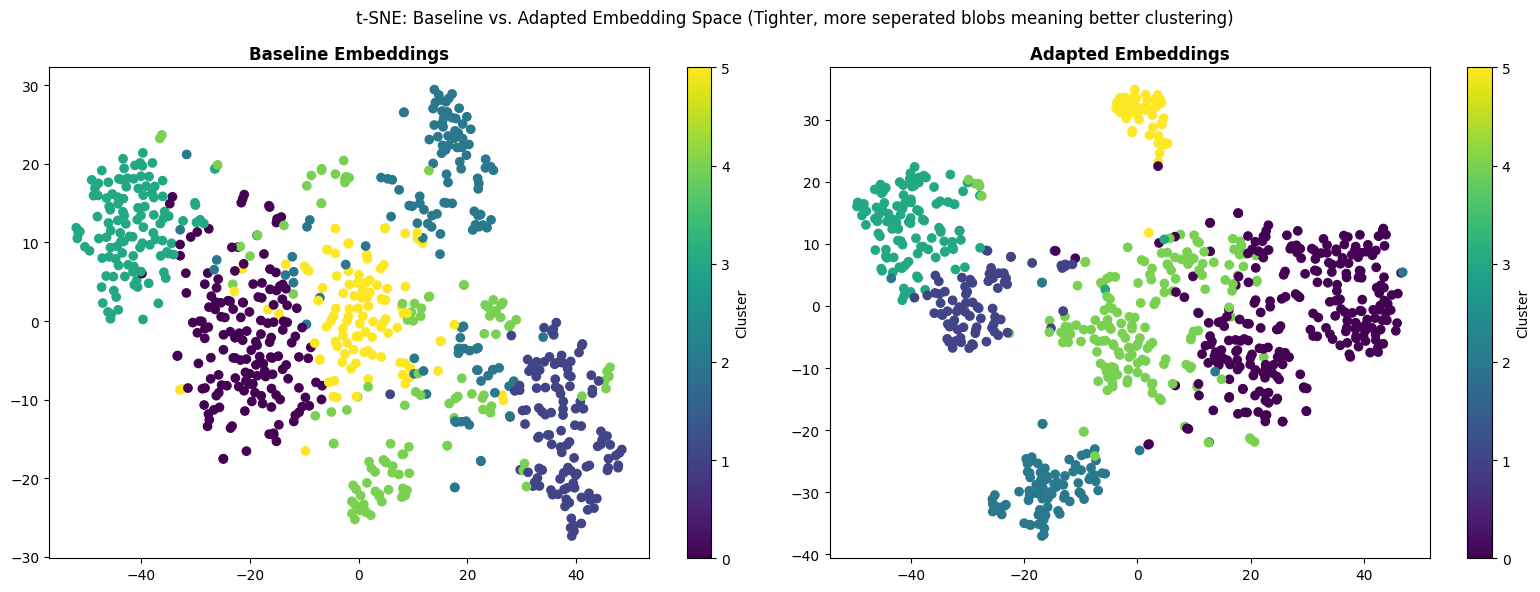

In [234]:
# Sharing the same CMAP (throughout the clusters)
CMAP = cm.get_cmap('tab10', N_CLUSTERS)

fig, axes = plt.subplots(1,2, figsize=(16, 6))
for ax, coords, labels, title in [
    (axes[0], tsne_baseline, baseline_labels, 'Baseline Embeddings'),
    (axes[1], tsne_adapted, adapted_labels, 'Adapted Embeddings'),
]:
    sc = ax.scatter(
        coords[:, 0], coords[:, 1], c=labels
    )
    ax.set_title(title, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='Cluster', ticks=range(N_CLUSTERS, ))

plt.suptitle(
    't-SNE: Baseline vs. Adapted Embedding Space (Tighter, more seperated blobs meaning better clustering)'
)
plt.tight_layout()
plt.savefig('cluster-viz.png', dpi=120, bbox_inches='tight')

## Cluster Metrics

In [247]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

### Silhouette Score

In [248]:
metrics: dict[str, float] = {}

metrics['silhouette-baseline'] = silhouette_score(baseline_embeddings, baseline_labels, random_state=RANDOM_SEED)
metrics['silhouette-adapted'] = silhouette_score(adapted_embeddings, adapted_labels, random_state=RANDOM_SEED)

### Davies-Bouldin Score

In [249]:
metrics['db-baseline'] = davies_bouldin_score(baseline_embeddings, baseline_labels)
metrics['db-adapted'] = davies_bouldin_score(adapted_embeddings, adapted_labels)

### Inter cluster distance

In [252]:
def inter_cluster_dist(embeddings, labels):
    unique = np.unique(labels)
    centroids = np.stack([embeddings[labels==lbl].mean(axis=0) for lbl in unique])
    n = len(centroids)
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            dists.append(float(np.linalg.norm(centroids[i] - centroids[j])))

    return float(np.mean(dists)) if dists else 0.0

In [255]:
metrics['inter-cluster-dist-baseline'] = inter_cluster_dist(baseline_embeddings, baseline_labels)
metrics['inter-cluster-dist-adapted'] = inter_cluster_dist(adapted_embeddings, adapted_labels)

In [256]:
metrics

{'silhouette-baseline': 0.07144250720739365,
 'silhouette-adapted': 0.08603274822235107,
 'db-baseline': 3.328022994489952,
 'db-adapted': 2.89539676774393,
 'inter-cluster-dist-baseline': 0.5475126365820567,
 'inter-cluster-dist-adapted': 0.6186890025933584}

In [261]:
results_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Score",
        "Inter-cluster Centroid Distance",
    ],
    "Baseline": [
        metrics["silhouette-baseline"],
        metrics["db-baseline"],
        metrics["inter-cluster-dist-baseline"],
    ],
    "Adapted": [
        metrics["silhouette-adapted"],
        metrics["db-adapted"],
        metrics["inter-cluster-dist-adapted"],
    ],
})

In [262]:
results_df

,Metric,Baseline,Adapted
0,Silhouette Score,0.071443,0.086033
1,Davies-Bouldin Score,3.328023,2.895397
2,Inter-cluster Centroid Distance,0.547513,0.618689


As we can see, our Adapted embedder's,

* Silhoette is higher (Improved)
* Davies Bouldin score have dropped (Improved)
* Inter-Cluster Centroid Distance have increased (Improved)

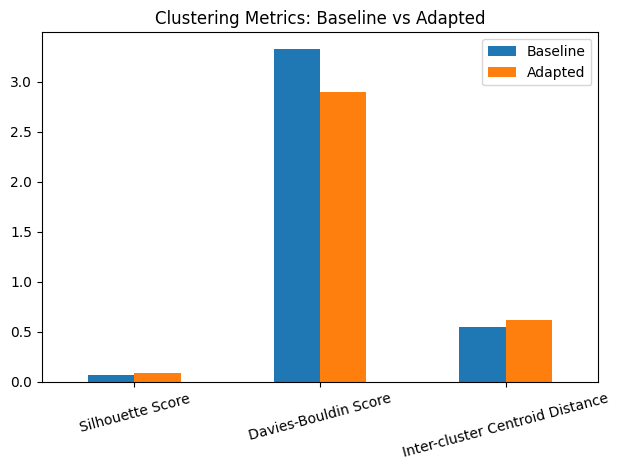

In [287]:
ax = results_df.plot(kind='bar')
ax.set_xticklabels(results_df.Metric, rotation=15)
ax.set_title('Clustering Metrics: Baseline vs Adapted')

fig = ax.get_figure()
plt.tight_layout()
fig.savefig('metrics-barchart.png')